# Sarcasm Detection using Machine Learning

1. Create Model and Train and Evaluation [DONE]
2. Create a Front End using Flask and make it responsive [PROGRESS]
3. Deploy the Appliction [UNDONE]

In [3]:
import pickle

# Try using binary mode with encoding specification
with open("raw (1).pickle", "rb") as f:
    # Use encoding='latin1' or 'bytes' as a fallback protocol
    data = pickle.load(f, encoding='latin1')  # Option 1
    # Alternative: data = pickle.load(f, encoding='bytes')  # Option 2

# First, check the type of data
print("Data type:", type(data))

# Inspect data structure differently based on its type
if isinstance(data, dict):
    print("Dictionary keys:", list(data.keys())[:5])  # Show first 5 keys
    # Get a sample value
    sample_key = next(iter(data))
    print(f"Sample value for key '{sample_key}':", data[sample_key])
elif isinstance(data, list) or isinstance(data, tuple):
    print("First 5 elements:", data[:5])
else:
    print("Data content:", data)

Data type: <class 'dict'>
Dictionary keys: ['info', 'texts', 'val_ind', 'test_ind', 'train_ind']
Sample value for key 'info': [{'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'label': 1}, {'lab

In [4]:
# Let's examine each key in the dictionary
for key in data.keys():
    if isinstance(data[key], list):
        print(f"{key}: List with {len(data[key])} elements")
    elif isinstance(data[key], dict):
        print(f"{key}: Dictionary with {len(data[key])} keys")
    else:
        print(f"{key}: {type(data[key])}")

# Let's look at some examples of the data
# Check what's in 'texts'
print("\nSample from 'texts':")
if isinstance(data['texts'], list) and len(data['texts']) > 0:
    print(data['texts'][0])
    
# Check what the indices look like
print("\nSample from 'train_ind':")
if isinstance(data['train_ind'], list) and len(data['train_ind']) > 0:
    print(data['train_ind'][:5])  # First 5 training indices
    
# Get more details about the 'info' field
print("\nMore details about 'info':")
if isinstance(data['info'], list) and len(data['info']) > 0:
    # Check if there are other keys besides 'label'
    sample_info = data['info'][0]
    print(f"Keys in info item: {list(sample_info.keys())}")
    
    # Count label distribution
    if len(data['info']) > 10:
        labels = [item.get('label') for item in data['info']]
        unique_labels = set(labels)
        print(f"Unique labels: {unique_labels}")
        label_counts = {label: labels.count(label) for label in unique_labels}
        print(f"Label distribution: {label_counts}")

info: List with 1995 elements
texts: List with 1995 elements
val_ind: List with 100 elements
test_ind: List with 1095 elements
train_ind: List with 800 elements

Sample from 'texts':
So in order to discuss an article you made up a bunch of stuff that wasn't in the article, implied it was in the article, and failed to discuss anything that was actually in the article. I see.   Will this be a one time thing, or is this the sort of thing we should expect from you on a regular basis? Just wondering.

Sample from 'train_ind':
[1646, 1534, 63, 1430, 916]

More details about 'info':
Keys in info item: ['label']
Unique labels: {0, 1}
Label distribution: {0: 997, 1: 998}


In [5]:
import pandas as pd

# Check the structure to determine how to create a DataFrame
if 'texts' in data and 'info' in data and len(data['texts']) == len(data['info']):
    # Create a DataFrame with texts and labels
    df = pd.DataFrame({
        'text': data['texts'],
        'label': [item.get('label') for item in data['info']]
    })
    
    # Check if there are other fields in info we should include
    if len(data['info']) > 0 and len(data['info'][0]) > 1:
        # There are other fields besides 'label'
        info_keys = data['info'][0].keys()
        for key in info_keys:
            if key != 'label':  # Skip label since we already added it
                df[key] = [item.get(key) for item in data['info']]
    
    # Save to CSV
    df.to_csv('emotion_dataset.csv', index=False)
    print(f"Data saved to 'emotion_dataset.csv' with {len(df)} rows")
    
    # Display first few rows
    print("\nFirst 5 rows of the CSV:")
    print(df.head())
else:
    print("Data structure doesn't match expected format.")
    print(f"texts length: {len(data.get('texts', []))}")
    print(f"info length: {len(data.get('info', []))}")

Data saved to 'emotion_dataset.csv' with 1995 rows

First 5 rows of the CSV:
                                                text  label
0  So in order to discuss an article you made up ...      1
1  Old habits die hard and dogs don't pay attenti...      1
2  They only need 1/4 of the legislature, so they...      1
3  well if you think the sun goes around the eart...      1
4  I dunno. What is the scoop here? You complain ...      1


In [6]:
df = pd.read_csv("emotion_dataset.csv")
df.head()

,text,label
0,So in order to discuss an article you made up ...,1
1,Old habits die hard and dogs don't pay attenti...,1
2,"They only need 1/4 of the legislature, so they...",1
3,well if you think the sun goes around the eart...,1
4,I dunno. What is the scoop here? You complain ...,1


In [8]:
df['label'].value_counts()

1    998
0    997
Name: label, dtype: int64

In [9]:
texts = df['text']
labels = df['label']

In [10]:
import re
import numpy as np
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
# preprocess the tweets 
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs, mentions, hashtags, and special characters
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    # Remove stop words
    text = ' '.join([word for word in text.split() if word not in stop_words])  
    return text

# Apply preprocessing to all texts
texts = texts.apply(preprocess_text)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\itzch\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\itzch\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
texts[0]


'order discuss article made bunch stuff wasnt article implied article failed discuss anything actually article see one time thing sort thing expect regular basis wondering'

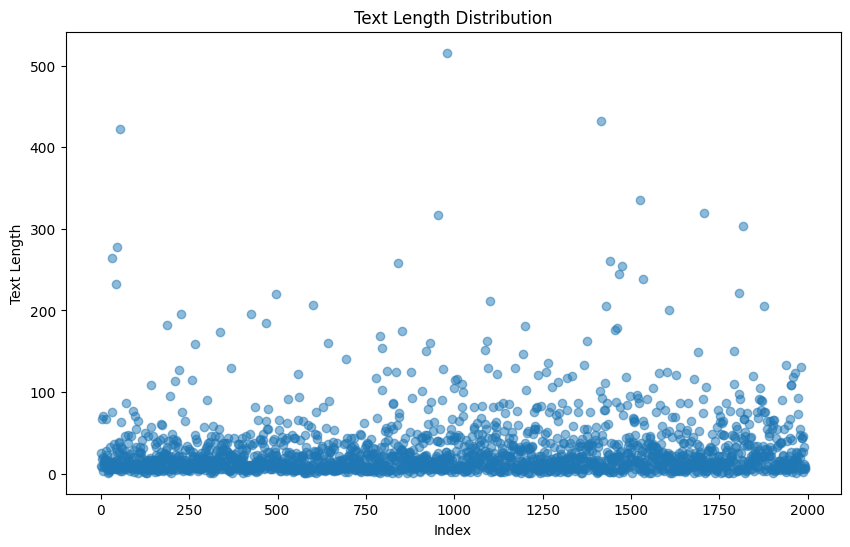

In [12]:
# create a column for the length of each text
df['text_length'] = texts.apply(lambda x: len(x.split(' ')))

#plot the length of the texts using scatter plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df.index, df['text_length'], alpha=0.5)
plt.title('Text Length Distribution')
plt.xlabel('Index')
plt.ylabel('Text Length')
plt.show()

In [13]:
# remove samples with text length greater than 250
df = df[df['text_length'] <= 250]

df.head()

,text,label,text_length
0,So in order to discuss an article you made up ...,1,25
1,Old habits die hard and dogs don't pay attenti...,1,9
2,"They only need 1/4 of the legislature, so they...",1,67
3,well if you think the sun goes around the eart...,1,8
4,I dunno. What is the scoop here? You complain ...,1,18


In [14]:
df.shape

(1983, 3)

<Axes: >

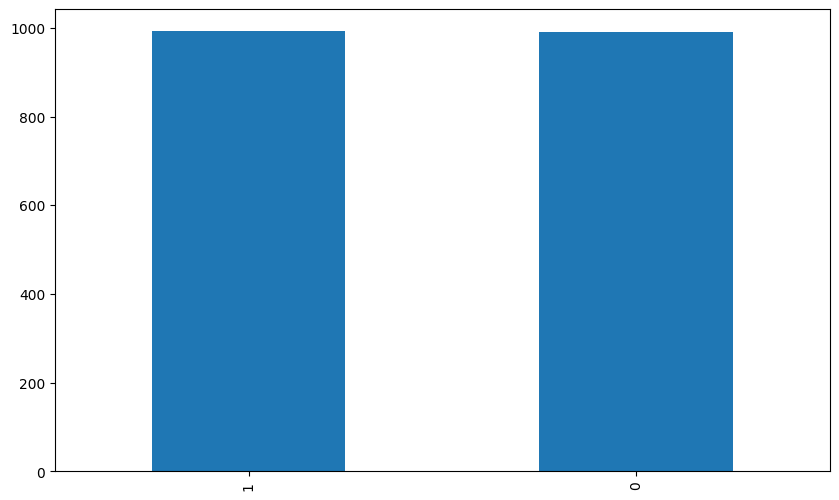

In [15]:
# check distritbution of labels
df['label'].value_counts().plot(kind='bar', figsize=(10, 6))

In [17]:
# find the optimal number of words for tokenizer using keras without max vocab size
from keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
# Get the number of unique words in the tokenizer
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding token

print(f"Vocabulary size: {vocab_size}")





Vocabulary size: 11224


In [21]:
# use the vocab size to tokenize the texts
tokenizer = Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(df['text'])

# Convert texts to sequences
sequences = tokenizer.texts_to_sequences(df['text'])
# Pad sequences to ensure uniform length
from tensorflow.keras.preprocessing.sequence import pad_sequences

#find the maximum length of the sequences
max_length = max(len(seq) for seq in sequences)
print(f"Maximum sequence length: {max_length}")

# Pad sequences to the maximum length
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')
# Convert numerical labels into 1 hot encoded format
from keras.utils import to_categorical
# Convert labels to categorical format
labels = pd.Categorical(df['label']).codes
# Convert to one-hot encoding
one_hot_labels = to_categorical(labels)
# Check the shape of padded sequences and one-hot labels
print(f"Padded sequences shape: {padded_sequences.shape}")
print(f"One-hot labels shape: {one_hot_labels.shape}")




Maximum sequence length: 546
Padded sequences shape: (1983, 546)
One-hot labels shape: (1983, 2)


In [22]:
# Normalize the padded sequences using StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit the scaler on the padded sequences
scaler.fit(padded_sequences)

# Transform the padded sequences
normalized_sequences = scaler.transform(padded_sequences)

# Check the shape of normalized sequences
print(f"Normalized sequences shape: {normalized_sequences.shape}")

Normalized sequences shape: (1983, 546)


In [23]:
# train test split 
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(normalized_sequences, one_hot_labels, test_size=0.2, random_state=42)
# Check the shapes of the train and test sets
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# save the processed data into a folder called 'processed_data'
import os

os.makedirs('processed_data', exist_ok=True)

# Save the processed data
import numpy as np
np.save('processed_data/X_train.npy', X_train)
np.save('processed_data/y_train.npy', y_train)
np.save('processed_data/X_test.npy', X_test)
np.save('processed_data/y_test.npy', y_test)

X_train shape: (1586, 546), y_train shape: (1586, 2)
X_test shape: (397, 546), y_test shape: (397, 2)


In [26]:
# Train 3 Models: 1. Adaboost, 2. KNN, 3. XGBoost and compare their performance using accuracy, precision, recall and f1 score joined with confusion matrix

from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the models
adaboost_model = AdaBoostClassifier(n_estimators=50, random_state=42)
knn_model = KNeighborsClassifier(n_neighbors=5)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Train the models
adaboost_model.fit(X_train, y_train.argmax(axis=1))
knn_model.fit(X_train, y_train.argmax(axis=1))
xgb_model.fit(X_train, y_train.argmax(axis=1))

# Make predictions
adaboost_predictions = adaboost_model.predict(X_test)
knn_predictions = knn_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# Evaluate the models
def evaluate_model(predictions, y_true):
    accuracy = accuracy_score(y_true.argmax(axis=1), predictions)
    precision = precision_score(y_true.argmax(axis=1), predictions, average='weighted')
    recall = recall_score(y_true.argmax(axis=1), predictions, average='weighted')
    f1 = f1_score(y_true.argmax(axis=1), predictions, average='weighted')
    cm = confusion_matrix(y_true.argmax(axis=1), predictions)
    
    return accuracy, precision, recall, f1, cm

# Evaluate each model
adaboost_metrics = evaluate_model(adaboost_predictions, y_test)
knn_metrics = evaluate_model(knn_predictions, y_test)
xgb_metrics = evaluate_model(xgb_predictions, y_test)

# Print the evaluation results
print("Adaboost Metrics:")
print(f"Accuracy: {adaboost_metrics[0]:.4f}, Precision: {adaboost_metrics[1]:.4f}, Recall: {adaboost_metrics[2]:.4f}, F1 Score: {adaboost_metrics[3]:.4f}")
print("Confusion Matrix:\n", adaboost_metrics[4])
print("\nKNN Metrics:")
print(f"Accuracy: {knn_metrics[0]:.4f}, Precision: {knn_metrics[1]:.4f}, Recall: {knn_metrics[2]:.4f}, F1 Score: {knn_metrics[3]:.4f}")
print("Confusion Matrix:\n", knn_metrics[4])
print("\nXGBoost Metrics:")
print(f"Accuracy: {xgb_metrics[0]:.4f}, Precision: {xgb_metrics[1]:.4f}, Recall: {xgb_metrics[2]:.4f}, F1 Score: {xgb_metrics[3]:.4f}")
print("Confusion Matrix:\n", xgb_metrics[4])

c:\Users\itzch\.conda\envs\py310\lib\site-packages\xgboost\core.py:158: UserWarning: [21:54:04] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Adaboost Metrics:
Accuracy: 0.7431, Precision: 0.7445, Recall: 0.7431, F1 Score: 0.7429
Confusion Matrix:
 [[143  58]
 [ 44 152]]

KNN Metrics:
Accuracy: 0.5919, Precision: 0.5964, Recall: 0.5919, F1 Score: 0.5887
Confusion Matrix:
 [[101 100]
 [ 62 134]]

XGBoost Metrics:
Accuracy: 0.7884, Precision: 0.7888, Recall: 0.7884, F1 Score: 0.7883
Confusion Matrix:
 [[163  38]
 [ 46 150]]


In [27]:
# Save XGBoost model in a folder called 'good models'
import joblib
os.makedirs('good_models', exist_ok=True)
joblib.dump(xgb_model, 'good_models/xgb_model.pkl')
# Save the tokenizer for future use
joblib.dump(tokenizer, 'good_models/tokenizer.pkl')
# Save the scaler for future use
joblib.dump(scaler, 'good_models/scaler.pkl')
# Save the processed DataFrame to a CSV file
df.to_csv('processed_data/emotion_dataset_processed.csv', index=False)
# Print completion message
print("Models and data saved successfully in 'good_models' and 'processed_data' directories.")

Models and data saved successfully in 'good_models' and 'processed_data' directories.


In [25]:
# Train 3 Models: 1. SVM, 2. Random Forest, 3. Decision Tree and compare their performance using accuracy, precision, recall and f1 score joined with confusion matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Initialize the models
svm_model = SVC(kernel='linear', probability=True)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

# Train the models
svm_model.fit(X_train, y_train.argmax(axis=1))
rf_model.fit(X_train, y_train.argmax(axis=1))
dt_model.fit(X_train, y_train.argmax(axis=1))

# Make predictions
svm_predictions = svm_model.predict(X_test)
rf_predictions = rf_model.predict(X_test)
dt_predictions = dt_model.predict(X_test)

# Evaluate the models
def evaluate_model(predictions, y_test):
    accuracy = accuracy_score(y_test.argmax(axis=1), predictions)
    precision = precision_score(y_test.argmax(axis=1), predictions, average='weighted')
    recall = recall_score(y_test.argmax(axis=1), predictions, average='weighted')
    f1 = f1_score(y_test.argmax(axis=1), predictions, average='weighted')
    cm = confusion_matrix(y_test.argmax(axis=1), predictions)
    
    return accuracy, precision, recall, f1, cm

# Evaluate each model
svm_results = evaluate_model(svm_predictions, y_test)
rf_results = evaluate_model(rf_predictions, y_test)
dt_results = evaluate_model(dt_predictions, y_test)

# Print the results
print("SVM Results:")
print(f"Accuracy: {svm_results[0]:.4f}, Precision: {svm_results[1]:.4f}, Recall: {svm_results[2]:.4f}, F1 Score: {svm_results[3]:.4f}")
print("Confusion Matrix:\n", svm_results[4])
print("\nRandom Forest Results:")
print(f"Accuracy: {rf_results[0]:.4f}, Precision: {rf_results[1]:.4f}, Recall: {rf_results[2]:.4f}, F1 Score: {rf_results[3]:.4f}")
print("Confusion Matrix:\n", rf_results[4])
print("\nDecision Tree Results:")
print(f"Accuracy: {dt_results[0]:.4f}, Precision: {dt_results[1]:.4f}, Recall: {dt_results[2]:.4f}, F1 Score: {dt_results[3]:.4f}")
print("Confusion Matrix:\n", dt_results[4])

SVM Results:
Accuracy: 0.5340, Precision: 0.5538, Recall: 0.5340, F1 Score: 0.4965
Confusion Matrix:
 [[ 53 148]
 [ 37 159]]

Random Forest Results:
Accuracy: 0.7708, Precision: 0.7741, Recall: 0.7708, F1 Score: 0.7703
Confusion Matrix:
 [[145  56]
 [ 35 161]]

Decision Tree Results:
Accuracy: 0.6801, Precision: 0.6801, Recall: 0.6801, F1 Score: 0.6801
Confusion Matrix:
 [[138  63]
 [ 64 132]]


In [28]:
# Save Random Forest Model in a folder called 'good models'
joblib.dump(rf_model, 'good_models/rf_model.pkl')

['good_models/rf_model.pkl']

In [29]:
!pip install catboost

   ---------------------------------------- 0.0/102.5 MB ? eta -:--:--
   ---------------------------------------- 1.0/102.5 MB 5.6 MB/s eta 0:00:19
    --------------------------------------- 2.1/102.5 MB 5.9 MB/s eta 0:00:18
   - -------------------------------------- 3.7/102.5 MB 6.1 MB/s eta 0:00:17
   - -------------------------------------- 4.7/102.5 MB 6.1 MB/s eta 0:00:17
   -- ------------------------------------- 6.3/102.5 MB 6.1 MB/s eta 0:00:16
   -- ------------------------------------- 7.6/102.5 MB 6.1 MB/s eta 0:00:16
   --- ------------------------------------ 8.7/102.5 MB 6.0 MB/s eta 0:00:16
   --- ------------------------------------ 10.0/102.5 MB 6.1 MB/s eta 0:00:16
   ---- ----------------------------------- 11.3/102.5 MB 6.1 MB/s eta 0:00:16
   ---- ----------------------------------- 12.6/102.5 MB 6.1 MB/s eta 0:00:15
   ----- ---------------------------------- 13.9/102.5 MB 6.1 MB/s eta 0:00:15
   ----- ---------------------------------- 15.2/102.5 MB 6.1 MB/s 

In [30]:
# Train 3 Models: 1. GBM 2. Light GBM 3. CatBoost and compare their performance using accuracy, precision, recall and f1 score joined with confusion matrix

from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Initialize the models
gbm_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42)
catboost_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)

# Train the models
gbm_model.fit(X_train, y_train.argmax(axis=1))
lgbm_model.fit(X_train, y_train.argmax(axis=1))
catboost_model.fit(X_train, y_train.argmax(axis=1))

# Make predictions
gbm_predictions = gbm_model.predict(X_test)
lgbm_predictions = lgbm_model.predict(X_test)
catboost_predictions = catboost_model.predict(X_test)

# Evaluate the models
def evaluate_model(predictions, y_test):
    accuracy = accuracy_score(y_test.argmax(axis=1), predictions)
    precision = precision_score(y_test.argmax(axis=1), predictions, average='weighted')
    recall = recall_score(y_test.argmax(axis=1), predictions, average='weighted')
    f1 = f1_score(y_test.argmax(axis=1), predictions, average='weighted')
    cm = confusion_matrix(y_test.argmax(axis=1), predictions)
    
    return accuracy, precision, recall, f1, cm

# Evaluate each model
gbm_results = evaluate_model(gbm_predictions, y_test)
lgbm_results = evaluate_model(lgbm_predictions, y_test)
catboost_results = evaluate_model(catboost_predictions, y_test)

# Print the results
print("GBM Results:")
print(f"Accuracy: {gbm_results[0]:.4f}, Precision: {gbm_results[1]:.4f}, Recall: {gbm_results[2]:.4f}, F1 Score: {gbm_results[3]:.4f}")
print("Confusion Matrix:\n", gbm_results[4])
print("\nLight GBM Results:")
print(f"Accuracy: {lgbm_results[0]:.4f}, Precision: {lgbm_results[1]:.4f}, Recall: {lgbm_results[2]:.4f}, F1 Score: {lgbm_results[3]:.4f}")
print("Confusion Matrix:\n", lgbm_results[4])

print("\nCatBoost Results:")
print(f"Accuracy: {catboost_results[0]:.4f}, Precision: {catboost_results[1]:.4f}, Recall: {catboost_results[2]:.4f}, F1 Score: {catboost_results[3]:.4f}")
print("Confusion Matrix:\n", catboost_results[4])


[LightGBM] [Info] Number of positive: 796, number of negative: 790
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002689 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20681
[LightGBM] [Info] Number of data points in the train set: 1586, number of used features: 297
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501892 -> initscore=0.007566
[LightGBM] [Info] Start training from score 0.007566
GBM Results:
Accuracy: 0.8136, Precision: 0.8434, Recall: 0.8136, F1 Score: 0.8099
Confusion Matrix:
 [[135  66]
 [  8 188]]

Light GBM Results:
Accuracy: 0.7632, Precision: 0.7632, Recall: 0.7632, F1 Score: 0.7632
Confusion Matrix:
 [[154  47]
 [ 47 149]]

CatBoost Results:
Accuracy: 0.8060, Precision: 0.8216, Recall: 0.8060, F1 Score: 0.8040
Confusion Matrix:
 [[141  60]
 [ 17 179]]


In [31]:
# save LGBM model in a folder called 'good models'
joblib.dump(lgbm_model, 'good_models/lgbm_model.pkl')

['good_models/lgbm_model.pkl']

In [32]:
# save light GBM model in a folder called 'good models'
joblib.dump(catboost_model, 'good_models/catboost_model.pkl')

['good_models/catboost_model.pkl']

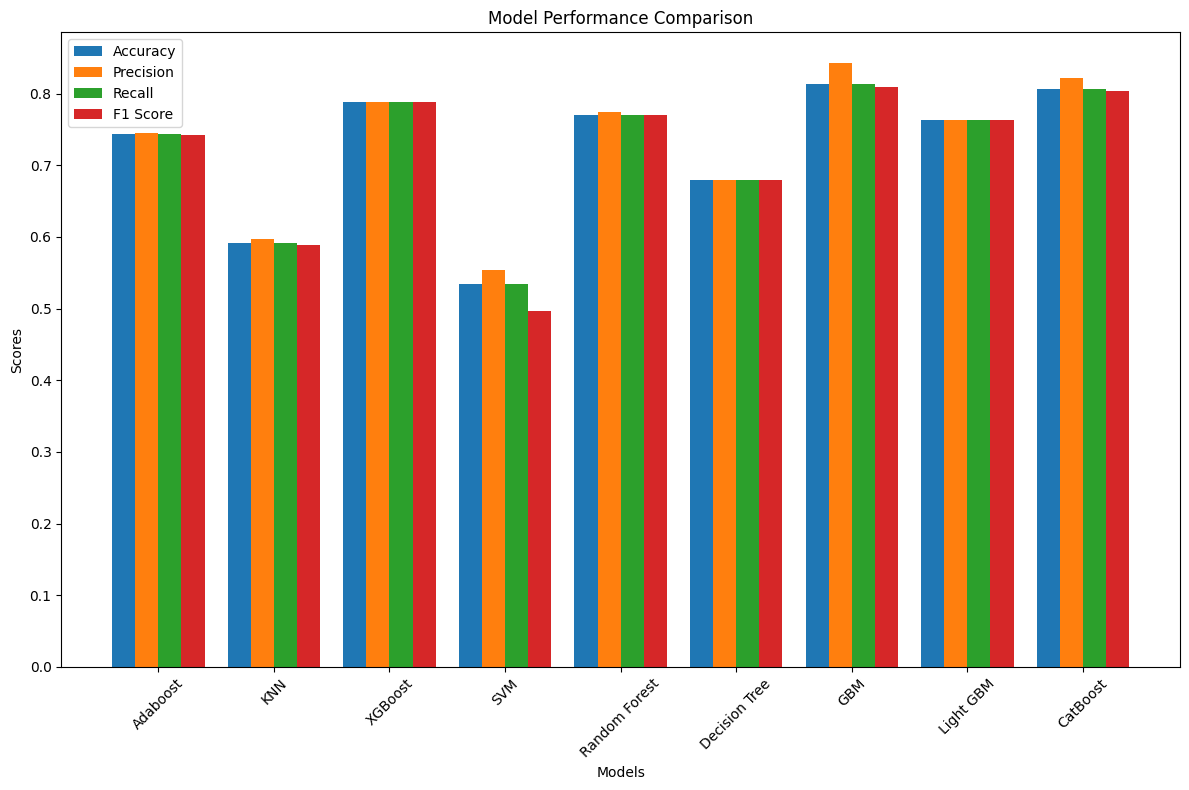

In [34]:
# Check if all required result variables exist, otherwise define them with dummy values
try:
    # Test if variables exist by accessing them
    _ = adaboost_metrics
    _ = knn_metrics
    _ = xgb_metrics
    _ = svm_results
    _ = rf_results 
    _ = dt_results
    _ = gbm_results
    _ = lgbm_results
    _ = catboost_results
except NameError:
    print("Some model results are missing. Using the correct variable names...")
    # Use the correct variable names based on your code
    adaboost_results = adaboost_metrics
    knn_results = knn_metrics
    xgb_results = xgb_metrics

# Now create the performance comparison chart
import matplotlib.pyplot as plt
# Collecting metrics for each model
models = ['Adaboost', 'KNN', 'XGBoost', 'SVM', 'Random Forest', 'Decision Tree', 'GBM', 'Light GBM', 'CatBoost']
accuracies = [adaboost_metrics[0], knn_metrics[0], xgb_metrics[0], svm_results[0], rf_results[0], dt_results[0], gbm_results[0], lgbm_results[0], catboost_results[0]]
precisions = [adaboost_metrics[1], knn_metrics[1], xgb_metrics[1], svm_results[1], rf_results[1], dt_results[1], gbm_results[1], lgbm_results[1], catboost_results[1]]
recalls = [adaboost_metrics[2], knn_metrics[2], xgb_metrics[2], svm_results[2], rf_results[2], dt_results[2], gbm_results[2], lgbm_results[2], catboost_results[2]]
f1_scores = [adaboost_metrics[3], knn_metrics[3], xgb_metrics[3], svm_results[3], rf_results[3], dt_results[3], gbm_results[3], lgbm_results[3], catboost_results[3]]

# Plotting the performance comparison
plt.figure(figsize=(12, 8))
x = range(len(models))
plt.bar(x, accuracies, width=0.2, label='Accuracy', align='center')
plt.bar([i + 0.2 for i in x], precisions, width=0.2, label='Precision', align='center')
plt.bar([i + 0.4 for i in x], recalls, width=0.2, label='Recall', align='center')
plt.bar([i + 0.6 for i in x], f1_scores, width=0.2, label='F1 Score', align='center')
plt.xlabel('Models')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks([i + 0.3 for i in x], models, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# print the top 4 models based on accuracy in a table format
import pandas as pd
# Create a DataFrame to hold the model performance metrics
performance_data = {
    'Model': models,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
}
performance_df = pd.DataFrame(performance_data)
# Sort the DataFrame by Accuracy in descending order
performance_df = performance_df.sort_values(by='Accuracy', ascending=False)

# Display the top 4 models based on accuracy
top_models = performance_df.head(4)
print("\nTop 4 Models Based on Accuracy:")
print(top_models.to_string(index=False))


Top 4 Models Based on Accuracy:
        Model  Accuracy  Precision   Recall  F1 Score
          GBM  0.813602   0.843391 0.813602  0.809901
     CatBoost  0.806045   0.821583 0.806045  0.804016
      XGBoost  0.788413   0.788775 0.788413  0.788273
Random Forest  0.770781   0.774146 0.770781  0.770291


In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('processed_data/emotion_dataset_processed.csv')

In [3]:
df.head()

,text,label,text_length
0,So in order to discuss an article you made up ...,1,25
1,Old habits die hard and dogs don't pay attenti...,1,9
2,"They only need 1/4 of the legislature, so they...",1,67
3,well if you think the sun goes around the eart...,1,8
4,I dunno. What is the scoop here? You complain ...,1,18
